Training FNN proposed in Collision detection, localization & classification for industrial robots with joint torque sensors with our dataset

https://ieeexplore.ieee.org/document/8172400

# 1. Load and convert labeled data

path/to/labeled_data/ 

    ├── class_0/
    │   ├── sample1.pkl
    │   ├── sample2.csv
    │   └── ...
    ├── class_1/
    │   ├── sample1.csv
    │   ├── sample2.pkl
    │   └── ...
    └── ...

dict_label={'class_0':0, 'class_1':1, ... }

# 2. Load AI Model

In [ ]:
import torch.nn as nn

class CollisionLocalizationNet(nn.Module):
    """
    A feed-forward neural network for collision localization.
    - Input: Joint torques (or other features)
    - Hidden Layer 1: 28 neurons
    - Hidden Layer 2: 14 neurons
    - Output: 7 classes (representing the link with the collision)
    """
    def __init__(self, input_size=7, num_classes=7):
        super(CollisionLocalizationNet, self).__init__()
        self.layer1 = nn.Linear(input_size, 28)
        self.layer2 = nn.Linear(28, 14)
        self.output_layer = nn.Linear(14, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        # No softmax needed here as CrossEntropyLoss will apply it internally
        x = self.output_layer(x)
        return x

# 3. Training

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import os
import sys
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import logging
import time
import pickle
import glob
from multiprocessing import Pool, cpu_count



def load_and_process_file(file_path):
    """Helper function to load and process a single CSV file."""
    match = re.search(r'link(\d+)', file_path)
    if match:
        link_label = int(match.group(1))
        df = pd.read_csv(file_path)
        collision_df = df[df['label'] == 1].copy()
        collision_df['target_link'] = link_label
        return collision_df
    return None

def train_localization_model(data_path, selected_features, num_epochs=50, batch_size=64, learning_rate=0.001):
    """
    Loads raw CSV data, splits each file for training and testing,
    filters for collisions, and trains the FNN with optimizations.
    """
    # --- 1. Optimized Data Loading ---
    all_csv_files = glob.glob(os.path.join(data_path, 'link*', '*.csv'))
    
    # Use multiprocessing to load files in parallel
    with Pool(processes=max(1, cpu_count() // 2)) as pool:
        data_frames = pool.map(load_and_process_file, all_csv_files)
    
    master_df = pd.concat([df for df in data_frames if df is not None], ignore_index=True)
    if master_df.empty:
        logging.error("No collision data found in the specified directory.")
        return None

    logging.info(f"Loaded and consolidated {len(master_df)} total collision samples using parallel processing.")

    X = master_df[selected_features].values
    y = master_df['target_link'].values - 1 

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    test_dataset = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())
    
    # --- 2. Optimized DataLoaders ---
    # Use num_workers > 0 and pin_memory=True for faster data transfer to GPU
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, 
                              num_workers=min(4, os.cpu_count()), pin_memory=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=min(4, os.cpu_count()), pin_memory=True)
    
    # --- 3. Initialize Model and Training Components ---
    model = CollisionLocalizationNet(input_size=len(selected_features), num_classes=len(np.unique(y_train)))
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # --- 4. Add Learning Rate Scheduler and Mixed Precision ---
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=learning_rate, steps_per_epoch=len(train_loader), epochs=num_epochs)
    scaler_amp = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    logging.info("--- Starting Optimized Model Training ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            # Use Automatic Mixed Precision (AMP)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            optimizer.zero_grad(set_to_none=True) # Use set_to_none for a small performance boost
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            
            scheduler.step()
            running_loss += loss.item()
            
        logging.info(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')
        
    # --- 5. Evaluation ---
    logging.info("--- Evaluating Model ---")
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        logging.info(f'Accuracy of the model on the test data: {100 * correct / total:.2f} %')
        
    return model, scaler

if __name__ == '__main__':
    # --- Configuration ---
    project_root = os.getcwd().replace('pipelines', '')  
    data_name = 'franka_main'
    dof = 7
    
    # Setup logging
    log_dir = os.path.join(project_root, 'pipelines', 'trained_models', data_name, 'contact_localization_FNN_simple')
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f'training_log_{time.time()}.txt')
    logging.basicConfig(level=logging.INFO,
                        format='%(asctime)s - %(levelname)s - %(message)s',
                        handlers=[logging.StreamHandler(), logging.FileHandler(log_file)])
    
    # --- Dataset Information ---
    data_directory = os.path.join(project_root, 'dataset', data_name, 'labeled_data')
    selected_features = [f'e{i}' for i in range(dof)]

    if not os.path.exists(data_directory):
        logging.error(f"Data directory not found at '{data_directory}'")
    else:
        trained_model, scaler = train_localization_model(data_directory, selected_features)
        
        if trained_model:
            # --- Save the Trained Model and the Scaler ---
            model_save_path = os.path.join(log_dir, 'FNN_localization_model_simple.pth')
            torch.save(trained_model.state_dict(), model_save_path)
            logging.info(f"\n✅ Model trained and saved to {model_save_path}")
            
            scaler_save_path = os.path.join(log_dir, 'scaler.pkl')
            with open(scaler_save_path, 'wb') as f:
                pickle.dump(scaler, f)
            logging.info(f"✅ Scaler saved to {scaler_save_path}")

2025-09-19 16:57:52,242 - INFO - Loaded and consolidated 745580 total collision samples using parallel processing.
2025-09-19 16:57:55,989 - INFO - --- Starting Optimized Model Training ---
2025-09-19 16:58:14,187 - INFO - Epoch [1/50], Loss: 1.6361, LR: 0.000050
2025-09-19 16:58:33,033 - INFO - Epoch [2/50], Loss: 1.2943, LR: 0.000081
2025-09-19 16:58:51,718 - INFO - Epoch [3/50], Loss: 1.1389, LR: 0.000132
2025-09-19 16:59:11,051 - INFO - Epoch [4/50], Loss: 1.0276, LR: 0.000199
2025-09-19 16:59:30,665 - INFO - Epoch [5/50], Loss: 0.9409, LR: 0.000280
2025-09-19 16:59:48,767 - INFO - Epoch [6/50], Loss: 0.8622, LR: 0.000372
2025-09-19 17:00:07,455 - INFO - Epoch [7/50], Loss: 0.7834, LR: 0.000470
2025-09-19 17:00:24,216 - INFO - Epoch [8/50], Loss: 0.7129, LR: 0.000570
2025-09-19 17:00:41,202 - INFO - Epoch [9/50], Loss: 0.6691, LR: 0.000668
2025-09-19 17:00:58,793 - INFO - Epoch [10/50], Loss: 0.6420, LR: 0.000760
2025-09-19 17:01:17,747 - INFO - Epoch [11/50], Loss: 0.6183, LR: 0.0

# 4. Evaluation

2025-09-19 17:23:33,194 - INFO - Successfully loaded model from /home/rzma/myProjects/contactInterpretation/pipelines/trained_models/franka_main/contact_localization_FNN_simple/FNN_localization_model_simple.pth and scaler from /home/rzma/myProjects/contactInterpretation/pipelines/trained_models/franka_main/contact_localization_FNN_simple/scaler.pkl
2025-09-19 17:23:33,260 - INFO - 
Evaluation Results for: g2_9.csv
2025-09-19 17:23:33,261 - INFO - Ground Truth Link: 1
2025-09-19 17:23:33,262 - INFO - Model Accuracy: 11.95%



Displaying plot. Close the plot window to exit.


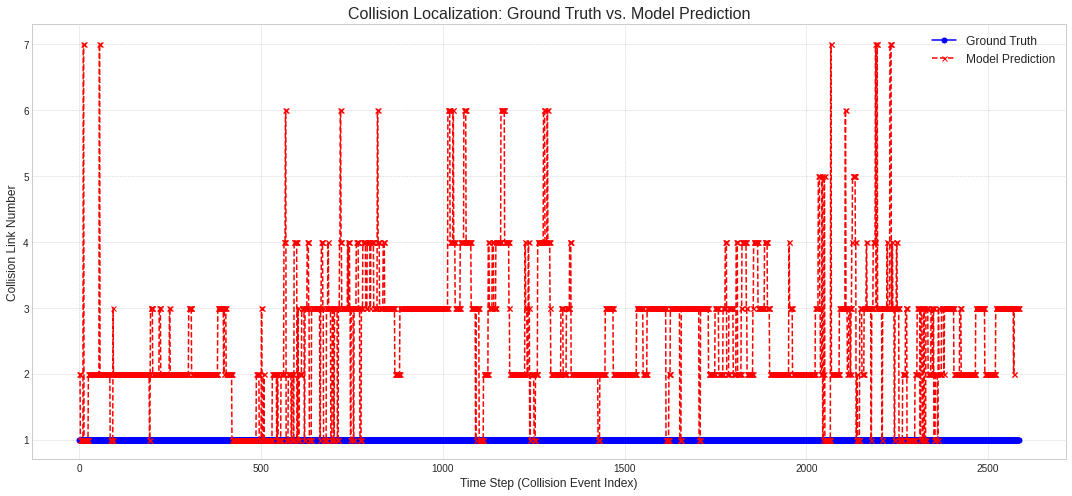

In [16]:
# single file evaluation script
import torch
import pandas as pd
import numpy as np
import os
import sys
import pickle
import re
import logging
import matplotlib.pyplot as plt


def plot_predictions(df_results):
    """
    Generates a plot to compare ground truth labels against model predictions.
    """
    # --- THIS IS THE FIX ---
    # Using a more compatible style name for older matplotlib versions
    plt.style.use('seaborn-whitegrid')
    # ---------------------
    
    fig, ax = plt.subplots(figsize=(15, 7))

    ax.plot(df_results.index, df_results['ground_truth'], 'o-', label='Ground Truth', color='blue', markersize=5)
    ax.plot(df_results.index, df_results['prediction'], 'x--', label='Model Prediction', color='red', markersize=5)

    ax.set_title('Collision Localization: Ground Truth vs. Model Prediction', fontsize=16)
    ax.set_xlabel('Time Step (Collision Event Index)', fontsize=12)
    ax.set_ylabel('Collision Link Number', fontsize=12)
    ax.legend(fontsize=12)
    ax.set_yticks(np.arange(1, 8, 1)) # Assuming links 1-7
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    print("\nDisplaying plot. Close the plot window to exit.")
    plt.show()


def evaluate_model(model_path, scaler_path, csv_path, selected_features):
    """
    Loads a trained model and scaler to make predictions on new CSV data and plots the results.
    """
    # --- 1. Load Model and Scaler ---
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
        
    input_size = len(selected_features)
    model = CollisionLocalizationNet(input_size=input_size, num_classes=7)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    logging.info(f"Successfully loaded model from {model_path} and scaler from {scaler_path}")

    # --- 2. Load and Preprocess Data ---
    df = pd.read_csv(csv_path)
    
    match = re.search(r'link(\d+)', csv_path)
    if not match:
        logging.error("Could not determine the ground truth link from the file path.")
        return
        
    ground_truth_link = int(match.group(1))
    
    collision_df = df[df['label'] == 1].copy()
    if collision_df.empty:
        logging.warning("No collision events (label=1) found in the specified CSV file.")
        return

    X = collision_df[selected_features].values
    X_scaled = scaler.transform(X)
    
    # --- 3. Make Predictions ---
    with torch.no_grad():
        inputs = torch.from_numpy(X_scaled).float().to(device)
        outputs = model(inputs)
        _, predicted_indices = torch.max(outputs.data, 1)
        predictions = predicted_indices.cpu().numpy() + 1

    # --- 4. Prepare for Plotting ---
    results_df = pd.DataFrame({
        'ground_truth': ground_truth_link,
        'prediction': predictions
    })
    
    logging.info(f"\nEvaluation Results for: {os.path.basename(csv_path)}")
    logging.info(f"Ground Truth Link: {ground_truth_link}")
    accuracy = np.mean(results_df['prediction'] == results_df['ground_truth']) * 100
    logging.info(f"Model Accuracy: {accuracy:.2f}%")
    
    plot_predictions(results_df)


if __name__ == '__main__':
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # --- Configuration ---
    data_name = 'franka_main'
    dof = 7
    selected_features = [f'e{i}' for i in range(dof)]
    
    model_dir = os.path.join(project_root, 'pipelines', 'trained_models', data_name, 'contact_localization_FNN_simple')
    model_path = os.path.join(model_dir, 'FNN_localization_model_simple.pth')
    scaler_path = os.path.join(model_dir, 'scaler.pkl')

    if not all(os.path.exists(p) for p in [model_path, scaler_path]):
        logging.error("Model or scaler file not found. Please train the model first using 'training_FNN_simple.py'.")
        sys.exit(1)
        
    # --- User Input for CSV File ---
    try:
        csv_to_evaluate = input("Please enter the full path to the CSV file you want to evaluate: ").strip()
        if not os.path.exists(csv_to_evaluate):
            logging.error(f"File not found: {csv_to_evaluate}")
        else:
            evaluate_model(model_path, scaler_path, csv_to_evaluate, selected_features)
    except (KeyboardInterrupt, EOFError):
        print("\nEvaluation cancelled.")

2025-09-19 17:28:51,847 - INFO - Successfully loaded model from /home/rzma/myProjects/contactInterpretation/pipelines/trained_models/franka_main/contact_localization_FNN_simple/FNN_localization_model_simple.pth and scaler from /home/rzma/myProjects/contactInterpretation/pipelines/trained_models/franka_main/contact_localization_FNN_simple/scaler.pkl
2025-09-19 17:29:11,383 - INFO - 
--- Overall Dataset Evaluation Complete ---
2025-09-19 17:29:11,384 - INFO - Total Collision Events Evaluated: 745580
2025-09-19 17:29:11,384 - INFO - Overall Model Accuracy: 82.87%



Displaying overall performance plot. Close the plot window to exit.


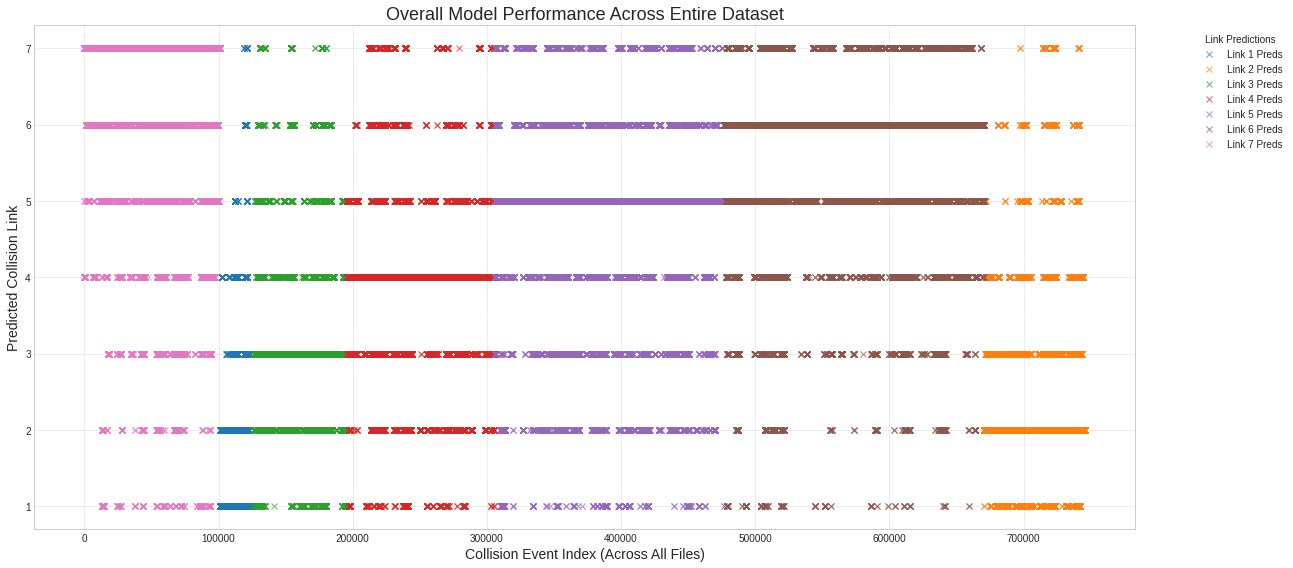

In [17]:
#evaluate full dataset script
import torch
import pandas as pd
import numpy as np
import os
import sys
import pickle
import re
import logging
import matplotlib.pyplot as plt
import glob

def plot_full_evaluation(df_results):
    """
    Generates a comprehensive plot for the entire dataset evaluation.
    """
    plt.style.use('seaborn-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 8))

    # For clarity, we'll plot each link's predictions and ground truth
    for link_num in sorted(df_results['ground_truth'].unique()):
        link_data = df_results[df_results['ground_truth'] == link_num]
        ax.plot(link_data.index, link_data['prediction'], 'x', label=f'Link {link_num} Preds', alpha=0.7)

    ax.set_title('Overall Model Performance Across Entire Dataset', fontsize=18)
    ax.set_xlabel('Collision Event Index (Across All Files)', fontsize=14)
    ax.set_ylabel('Predicted Collision Link', fontsize=14)
    ax.legend(title='Link Predictions', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_yticks(np.arange(1, 8, 1))
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    print("\nDisplaying overall performance plot. Close the plot window to exit.")
    plt.show()


def evaluate_full_dataset(model_path, scaler_path, data_path, selected_features):
    """
    Loads a model and evaluates it against all CSV files in the dataset directory.
    """
    # --- 1. Load Model and Scaler ---
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
        
    input_size = len(selected_features)
    model = CollisionLocalizationNet(input_size=input_size, num_classes=7)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    logging.info(f"Successfully loaded model from {model_path} and scaler from {scaler_path}")

    # --- 2. Find and Process All CSV Files ---
    all_csv_files = glob.glob(os.path.join(data_path, 'link*', '*.csv'))
    if not all_csv_files:
        logging.error(f"No CSV files found in the directory: {data_path}")
        return

    all_results = []

    for csv_file in all_csv_files:
        match = re.search(r'link(\d+)', csv_file)
        if not match:
            continue
        
        ground_truth_link = int(match.group(1))
        df = pd.read_csv(csv_file)
        collision_df = df[df['label'] == 1].copy()

        if not collision_df.empty:
            X = collision_df[selected_features].values
            X_scaled = scaler.transform(X)
            
            with torch.no_grad():
                inputs = torch.from_numpy(X_scaled).float().to(device)
                outputs = model(inputs)
                _, predicted_indices = torch.max(outputs.data, 1)
                predictions = predicted_indices.cpu().numpy() + 1
            
            results_df = pd.DataFrame({
                'ground_truth': ground_truth_link,
                'prediction': predictions
            })
            all_results.append(results_df)

    # --- 3. Consolidate and Analyze Results ---
    if not all_results:
        logging.warning("No collision events were found across the entire dataset.")
        return

    final_results_df = pd.concat(all_results, ignore_index=True)
    
    accuracy = np.mean(final_results_df['prediction'] == final_results_df['ground_truth']) * 100
    logging.info("\n--- Overall Dataset Evaluation Complete ---")
    logging.info(f"Total Collision Events Evaluated: {len(final_results_df)}")
    logging.info(f"Overall Model Accuracy: {accuracy:.2f}%")
    
    # --- 4. Plot Overall Performance ---
    plot_full_evaluation(final_results_df)


if __name__ == '__main__':
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # --- Configuration ---
    data_name = 'franka_main'
    dof = 7
    selected_features = [f'e{i}' for i in range(dof)]
    
    model_dir = os.path.join(project_root, 'pipelines', 'trained_models', data_name, 'contact_localization_FNN_simple')
    model_path = os.path.join(model_dir, 'FNN_localization_model_simple.pth')
    scaler_path = os.path.join(model_dir, 'scaler.pkl')

    if not all(os.path.exists(p) for p in [model_path, scaler_path]):
        logging.error("Model or scaler file not found. Please train the model first using 'training_FNN_simple.py'.")
        sys.exit(1)
        
    data_directory = os.path.join(project_root, 'dataset', data_name, 'labeled_data')
    if not os.path.exists(data_directory):
        logging.error(f"Data directory not found: {data_directory}")
    else:
        evaluate_full_dataset(model_path, scaler_path, data_directory, selected_features)